## Introduction

Problem Definition:
Predicting k_inf and PPPF in nuclear reactors is essential but traditional simulations are slow and expensive.

Project Goal:
This is a Regression project. The goal is to use Machine Learning to predict k_inf and PPPF from 39 reactor features.


Importance:
Accurate prediction helps ensure reactor safety and speeds up design.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib


## Dataset Selection

## 1. Dataset Loading & Column Naming
In this cell we load the raw dataset from raw.csv.  
The file has no header and columns are space-separated.  
We assign column names: k_inf and PPPF as targets, and feature_1 to feature_39 as inputs.
Then we display the first 5 rows and dataset shape.

In [ ]:

df = pd.read_csv('raw.csv', sep=r'\s+', header=None)
print('\n')
feature_names = [f'feature_{i}' for i in range(1,40)]
df.columns = ['k_inf', 'PPPF']+feature_names
print(df.head())
print(df.shape)






     k_inf      PPPF  feature_1  feature_2  feature_3  feature_4  feature_5  \
0  1.32630  1.862086   3.562615   1.112359   4.208065   1.412679   2.271031   
1  1.34149  1.786558   2.354766   1.047929   2.268974   4.637777   3.793194   
2  1.33034  1.826187   3.037997   4.719517   1.502280   3.644736   3.575727   
3  1.35653  1.739225   4.412804   2.220680   3.132738   1.327124   4.759890   
4  1.30190  1.955829   2.790669   0.798177   1.231750   1.977844   2.393930   

   feature_6  feature_7  feature_8  ...  feature_30  feature_31  feature_32  \
0   3.950614   3.627032   4.600332  ...    3.965987    4.030999    0.826347   
1   2.859702   4.361058   3.592485  ...    2.228000    4.837370    2.846538   
2   1.337686   2.380347   4.503771  ...    2.615278    3.757999    3.161658   
3   2.882082   3.663430   4.531524  ...    3.899026    1.018926    4.379308   
4   4.738126   1.364743   3.391665  ...    3.641512    1.564076    2.178406   

   feature_33  feature_34  feature_35  feature_3

## Data Cleaning


We checked the dataset for missing values and duplicates.  
Result: No missing values and no duplicate rows were found.  


In [ ]:
print(df.isnull().sum())
print("Missing Value : ",df.isnull().sum().sum())

print("duplicated : ",df.duplicated().sum())
print(df.shape)

k_inf         0
PPPF          0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27    0
feature_28    0
feature_29    0
feature_30    0
feature_31    0
feature_32    0
feature_33    0
feature_34    0
feature_35    0
feature_36    0
feature_37    0
feature_38    0
feature_39    0
dtype: int64
Missing Value :  0
duplicated :  0
(24000, 41)


## Exploratory Data Analysis (EDA)


- Used describe() to get basic statistics of the dataset.
- Plotted distribution of target variables: k_inf and PPPF using histograms.
- Generated a correlation heatmap to understand relationships between features and targets.


              k_inf          PPPF     feature_1     feature_2     feature_3  \
count  24000.000000  24000.000000  24000.000000  24000.000000  24000.000000   
mean       1.325139      1.883559      2.855694      2.859994      2.857451   
std        0.017798      0.120018      1.240040      1.238304      1.237204   
min        1.246360      1.527497      0.700055      0.700098      0.700080   
25%        1.313650      1.798641      1.778343      1.784898      1.785185   
50%        1.326085      1.876336      2.855621      2.869736      2.873263   
75%        1.337683      1.960852      3.935998      3.931073      3.921500   
max        1.385580      2.473015      4.999537      4.999781      4.999613   

          feature_4     feature_5     feature_6     feature_7     feature_8  \
count  24000.000000  24000.000000  24000.000000  24000.000000  24000.000000   
mean       2.867554      2.848997      2.840123      2.867360      2.850948   
std        1.234584      1.243988      1.242275    

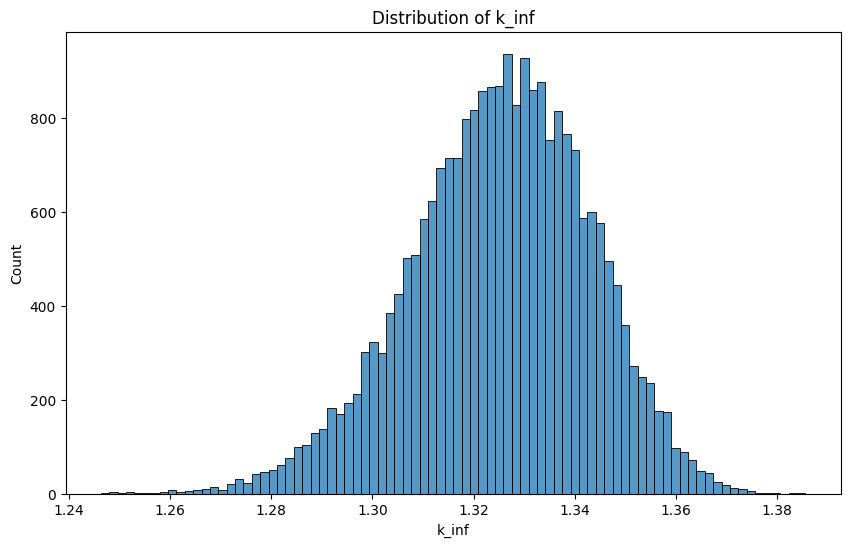

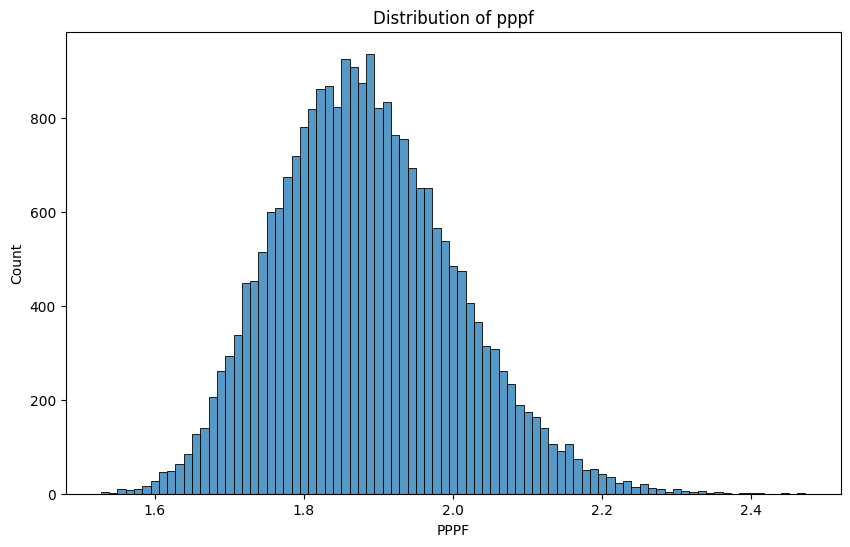

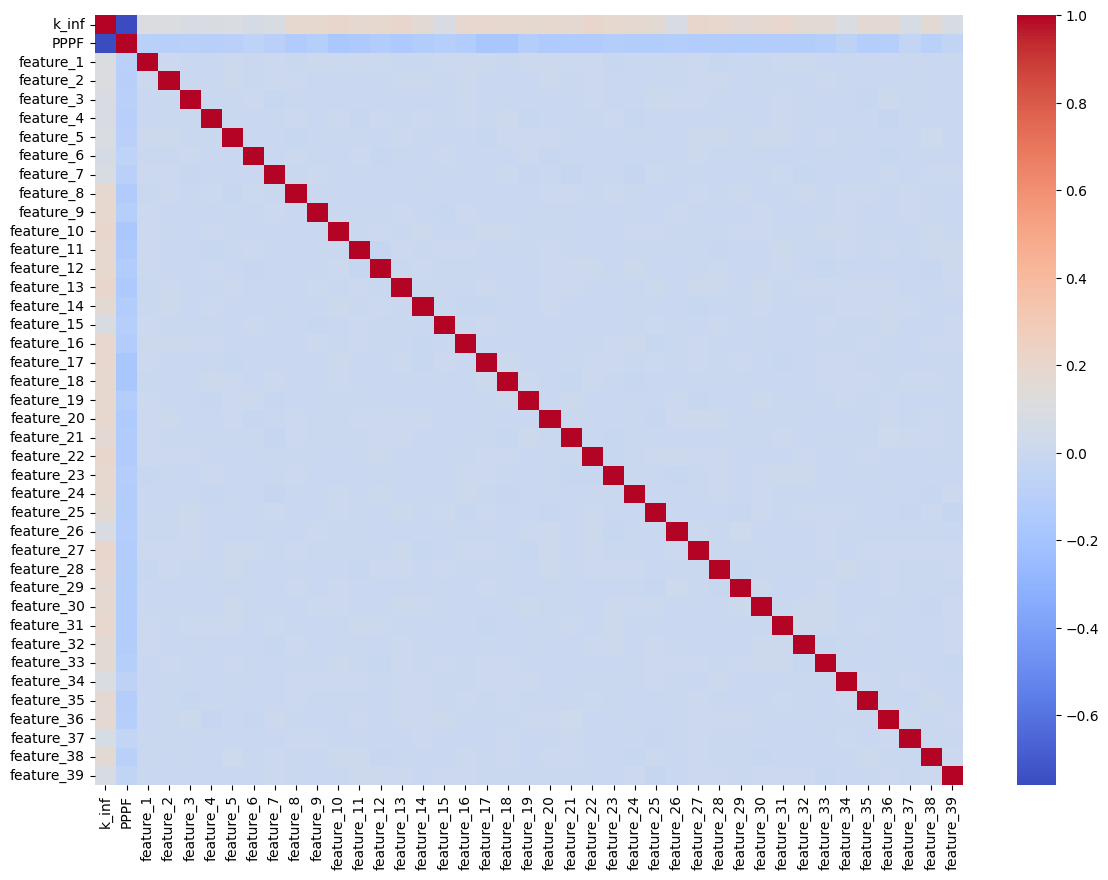

In [ ]:

print(df.describe())
k_inf = 'k_inf'
pppf = 'PPPF'

plt.figure(figsize=(10,6))
sns.histplot(df[k_inf])
plt.title("Distribution of k_inf")
plt.show()
print('\n')
plt.figure(figsize=(10,6))
sns.histplot(df[pppf])
plt.title("Distribution of pppf")
plt.show()

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')

plt.show()





## Data preprocessing


1.  Split Features and Targets: Separated X and y.
2.  Train-Test Split: 80% for training and 20% for testing.
3.  Feature Scaling: Applied StandardScaler to normalize features.


In [ ]:


x = df.drop(columns=['k_inf', 'PPPF'])
y = df[['k_inf', 'PPPF']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



scaler_x = StandardScaler()
x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

print(x_train.shape)
print(x_test.shape)




(19200, 39)
(4800, 39)


## Feature Engineering


To reduce dimensionality and improve model performance:
1.  Feature Selection: Used SelectKBest with f_regression to select the top 25 most relevant features for k_inf.
2.  Dimensionality Reduction: Applied PCA with 10 components to capture the most important variance.  
Result: Reduced features from 39 to 10.

And so it is with pppf

In [37]:


selector_k_inf = SelectKBest(score_func=f_regression, k=25)
x_train_selected_k_inf = selector_k_inf.fit_transform(x_train, y_train['k_inf'])
x_test_selected_k_inf = selector_k_inf.transform(x_test)

print(x_train_selected_k_inf.shape)
print(x_test_selected_k_inf.shape)



pca = PCA(n_components=10)
x_train_pca_k_inf = pca.fit_transform(x_train_selected_k_inf)
x_test_pca_k_inf = pca.transform(x_test_selected_k_inf)

print(x_train_pca_k_inf.shape)


print('\n')



selector_pppf = SelectKBest(score_func=f_regression, k=25)
x_train_selected_pppf = selector_pppf.fit_transform(x_train, y_train['PPPF'])
x_test_selected_pppf = selector_pppf.transform(x_test)

print(x_train_selected_pppf.shape)
print(x_test_selected_pppf.shape)


pca = PCA(n_components=10)
x_train_pca_pppf = pca.fit_transform(x_train_selected_pppf)
x_test_pca_pppf = pca.transform(x_test_selected_pppf)

print(x_train_pca_pppf.shape)


(19200, 25)
(4800, 25)


(19200, 25)
(4800, 25)
(19200, 10)


## Model Building


We trained 4 regression models to predict each target separately using the 10 PCA components:


- Random Forest Regressor
- Gradient Boosting Regressor  
- AdaBoost Regressor
- XGBoost Regressor

 The same 4 models were trained for both k_inf and PPPF targets.

In [ ]:


rf_k_inf = RandomForestRegressor  (n_estimators=300, random_state=42)
rf_k_inf.fit(x_train_scaled, y_train['k_inf'])
rf_k_inf_pred=rf_k_inf.predict(x_test_scaled)



gb_k_inf = GradientBoostingRegressor  (n_estimators=300,random_state=42)
gb_k_inf.fit(x_train_scaled, y_train['k_inf'])
gb_k_inf_pred=gb_k_inf.predict(x_test_scaled)


ada = AdaBoostRegressor(random_state=42)
ada.fit(x_train_scaled, y_train['k_inf'])
ada_k_inf_pred=ada.predict(x_test_scaled)



xgb_k_inf = XGBRegressor  (n_estimators=300, random_state=42)
xgb_k_inf.fit(x_train_scaled, y_train['k_inf'])
xgb_k_inf_pred=xgb_k_inf.predict(x_test_scaled)





rf_pppf = RandomForestRegressor  (n_estimators=300, random_state=42)
rf_pppf.fit(x_train_scaled, y_train['PPPF'])
rf_pppf_pred=rf_pppf.predict(x_test_scaled)


gb_pppf = GradientBoostingRegressor  (n_estimators=300, random_state=42)
gb_pppf.fit(x_train_scaled, y_train['PPPF'])
gb_pppf_pred=gb_pppf.predict(x_test_scaled)


ada = AdaBoostRegressor(random_state=42)
ada.fit(x_train_scaled, y_train['PPPF'])
ada_pppf_pred=ada.predict(x_test_scaled)


xgb_pppf = XGBRegressor  (n_estimators=300, random_state=42)
xgb_pppf.fit(x_train_scaled, y_train['PPPF'])
xgb_pppf_pred=xgb_pppf.predict(x_test_scaled)



## Model Evaluation


We evaluated all 4 models using R² Score and MSE for both targets.



In [ ]:

print('k_inf')
print('Random Forest')
print("R2 Score :", r2_score(y_test['k_inf'], rf_k_inf_pred))
print("MSE:", mean_squared_error(y_test['k_inf'], rf_k_inf_pred))

print('\n')
print('GradientBoosting')
print("R2 Score:", r2_score(y_test['k_inf'], gb_k_inf_pred))
print("MSE:", mean_squared_error(y_test['k_inf'], gb_k_inf_pred))

print('\n')
print('AdaBoostRegressor')
print("R2 Score:", r2_score(y_test['k_inf'], ada_k_inf_pred))
print("MSE:", mean_squared_error(y_test['k_inf'], ada_k_inf_pred))

print('\n')
print('XGBRegressor')
print("R2 Score:", r2_score(y_test['k_inf'], xgb_k_inf_pred))
print("MSE:", mean_squared_error(y_test['k_inf'], xgb_k_inf_pred))

print('\n \n \n')
print('PPPF')

print('Random Forest')
print("R2 Score:", r2_score(y_test['PPPF'], rf_pppf_pred))
print("MSE:", mean_squared_error(y_test['PPPF'], rf_pppf_pred))

print('\n')
print('GradientBoosting')
print("R2 Score:", r2_score(y_test['PPPF'], gb_pppf_pred))
print("MSE:", mean_squared_error(y_test['PPPF'], gb_pppf_pred))

print('\n')
print('AdaBoostRegressor')
print("R2 Score:", r2_score(y_test['PPPF'], ada_pppf_pred))
print("MSE:", mean_squared_error(y_test['PPPF'], ada_pppf_pred))

print('\n')
print('XGBRegressor')
print("R2 Score:", r2_score(y_test['PPPF'], xgb_pppf_pred))
print("MSE:", mean_squared_error(y_test['PPPF'], xgb_pppf_pred))


k_inf
Random Forest
R2 Score : 0.5883604537439838
MSE: 0.00012974575695070387


GradientBoosting
R2 Score: 0.9089906857435331
MSE: 2.8685466387201364e-05


AdaBoostRegressor
R2 Score: 0.5416311878637581
MSE: 0.0001444744778146847


XGBRegressor
R2 Score: 0.8606932005613244
MSE: 4.390847843931298e-05

 
 

PPPF
Random Forest
R2 Score: 0.4379125025974475
MSE: 0.008227689889463947


GradientBoosting
R2 Score: 0.7259760649470086
MSE: 0.004011090747126061


AdaBoostRegressor
R2 Score: 0.341830077504648
MSE: 0.009634119317523332


XGBRegressor
R2 Score: 0.7385143001259743
MSE: 0.003827559337353721


Model Optimization

In [ ]:


model_k_inf = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,

    random_state=42,

)

model_pppf = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,

    random_state=42,

)


model_k_inf.fit(x_train_scaled, y_train['k_inf'])


model_pppf.fit(x_train_scaled, y_train['PPPF'])



y_pred_k_inf = model_k_inf.predict(x_test_scaled)
y_pred_pppf = model_pppf.predict(x_test_scaled)


r2_k_inf = r2_score(y_test['k_inf'], y_pred_k_inf)
r2_pppf = r2_score(y_test['PPPF'], y_pred_pppf)

mse_k_inf = mean_squared_error(y_test['k_inf'], y_pred_k_inf)
mse_pppf = mean_squared_error(y_test['PPPF'], y_pred_pppf)


print(f"R2 k_inf:  {r2_k_inf:.4f}")
print(f"R2 PPPF:  {r2_pppf:.4f}")
print(f"MSE k_inf: {mse_k_inf:.6f}")
print(f"MSE PPPF: {mse_pppf:.6f}")




R2 k_inf:  0.9815
R2 PPPF:  0.8307
MSE k_inf: 0.000006
MSE PPPF: 0.002477


In [ ]:

joblib.dump(model_k_inf, 'k_inf_model.pkl')
joblib.dump(model_pppf, 'pppf_model.pkl')

['pppf_model.pkl']